## Comparative Performance of ChatGPT and Claude for Automated Extraction of J-V Data from Solar Cell Images

This study developed an automated pipeline for extracting J-V curve data from photovoltaic solar cell images using Large Language Models. Six models from OpenAI (ChatGPT) and Anthropic (Claude) were benchmarked against real experimental data using R² as the accuracy metric. GPT-5.5 achieved near-perfect extraction with R²=0.9982, while Claude Sonnet and opus offered the best cost-accuracy balance at R²=0.80 to 0.94 (reproducibility not good). The pipeline reduces manual digitization time from 10-30 minutes to under 60 seconds per curve, enabling scalable data extraction from large volumes of published literature.

# 1. Claude 

In [1]:
import anthropic
from dotenv import load_dotenv
import os

In [2]:
# Load the API key
load_dotenv()
api_key = os.environ.get('ANTHROPIC_API_KEY')
if api_key:
    print('API key is successfully taken')

API key is successfully taken


In [3]:
# Crate a client for API access
client = anthropic.Anthropic(api_key=api_key)

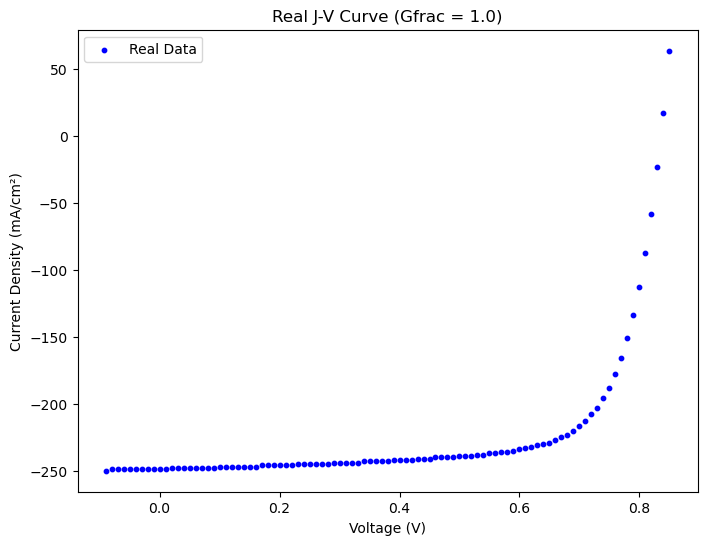

In [4]:
# This is a sample J-V data (Experimental at 0 sun intensity)
# At this stage we will be using this plot for the extraction.
import pandas as pd
import matplotlib.pyplot as plt

# Load and filter data
data = pd.read_csv("0min_cell_4.csv")
data = data[data["Gfrac"] == 1.0]
jv_data = data[(data["Vext"] > -0.1) & (data["Jext"] < 100)]
jv_data = jv_data.reset_index(drop=True)

# Plot and save as image
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(jv_data["Vext"], jv_data["Jext"], color="blue", s=10, label="Real Data")
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Current Density (mA/cm²)")
ax.set_title("Real J-V Curve (Gfrac = 1.0)")
ax.legend()
#ax.grid(True, alpha=0.3)

# Save to images folder
plt.savefig("image/jv_real.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from PIL import Image
img = Image.open("image/jv_real.png")
print("Width:", img.size[0], "pixels")
print("Height:", img.size[1], "pixels")
print("Full size:", img.size)
print("DPI:", img.info.get("dpi", "Not stored in file"))
print("Mode:", img.mode)  # RGB, RGBA etc

Width: 1060 pixels
Height: 817 pixels
Full size: (1060, 817)
DPI: (150.01239999999999, 150.01239999999999)
Mode: RGBA


# Claude returns better result if we increase the resolution.

In [ ]:
from PIL import Image, ImageEnhance, ImageFilter

img = Image.open("image/jv_real.png")
# Upscale
img = img.resize((6000, 8000), Image.LANCZOS)
# Sharpen
img = img.filter(ImageFilter.SHARPEN)
# Increase contrast
enhancer = ImageEnhance.Contrast(img)
img = enhancer.enhance(2.0)
img.save("image/figure_enhanced_2.png", dpi=(400,400))
img

In [ ]:
from PIL import Image
img = Image.open("image/figure_enhanced_2.png")
print("Width:", img.size[0], "pixels")
print("Height:", img.size[1], "pixels")
print("Full size:", img.size)
print("DPI:", img.info.get("dpi", "Not stored in file"))
print("Mode:", img.mode)  # RGB, RGBA etc

In [6]:
import base64
from pathlib import Path

image_path = Path('image/jv_real.png')
if image_path.exists():
    print('Image found')
else:
    print('Image not found')

Image found


In [7]:
# Read the image as raw bytes
image_bytes = image_path.read_bytes()
# Convert raw bytes to base64 string
base64_image = base64.b64encode(image_bytes).decode("utf-8")
print("Type:", type(base64_image))
print("First 50 characters:", base64_image[:50])

Type: <class 'str'>
First 50 characters: iVBORw0KGgoAAAANSUhEUgAABCQAAAMxCAYAAAAzKmKvAAAAOX


In [8]:
import json
import re

response_claude = client.messages.create(
    model="claude-sonnet-4-6",
    #model="claude-opus-4-5",
    max_tokens=4000,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "source": {
                        "type": "base64",
                        "media_type": "image/png",
                        "data": base64_image,
                    },
                },
                {
                    "type": "text",
                    "text": """I am a photovoltaic solar cell researcher. This is my own experimental J-V curve image.
I lost the original numerical data file, so I need to digitize the visible curve from this image.
You are an expert in photovoltaic J-V curve analysis and scientific plot digitization.
IMPORTANT:
- Perform the best possible visual digitization from the image.
- Do not suggest WebPlotDigitizer, Engauge Digitizer, or any other external tools.
- The extracted values must be based only on the visible experimental curve.
- Return JSON only. No explanation, no markdown, no extra text.
Your tasks:
1. Identify the plot area only.
   - Ignore margins, legend, title, axis labels, and other text outside the plot box.
   - Use only the actual plotting region for calibration.
2. Read the axes carefully.
   - x-axis: Voltage, unit V.
   - y-axis: Current Density, unit mA/cm^2.
   - Pay special attention to negative current-density values.
3. Extract data points:
   - Map tick label positions to real V and J values to calibrate pixel-to-value conversion.
   - Detect the maximum power point/knee region of the curve.
   - In this region, read both V and J coordinates very carefully.
   - Small pixel errors can cause large J errors in the steep region.
   - Cross-check each point against the nearest tick labels.
   - Extract 1 point every 0.01V across flat regions of the visible curve.
   - Extract 1 point every 0.005V across knee and forward-bias regions of the visible J-V curve.
   - Do NOT stop extraction at Voc.
   - Voc is only the voltage where J crosses 0 mA/cm^2.
   - Positive current density values above 0 mA/cm^2 are valid experimental J-V data.
   - If the visible curve extends above J = 0, the final data_points list must include positive J values.
   - CRITICAL: Only extract a point if the experimental curve or marker is CLEARLY VISIBLE at that voltage.
   - Do NOT guess, interpolate, or invent points between visible markers.
   - Read from the center of the visible curve line or marker.
   - Ignore axes, grid lines, legend symbols, and text.
4. Sort all extracted points by increasing voltage.
Return the answer in this exact JSON structure:
{
  "data_points": [
    {"V": 0.00, "J": 0.00}
  ]
}"""
                }
            ],
        }
    ],
)

raw_text_claude = response_claude.content[0].text
print(raw_text_claude)

```json
{
  "data_points": [
    {"V": -0.10, "J": -248.5},
    {"V": -0.09, "J": -248.5},
    {"V": -0.08, "J": -248.4},
    {"V": -0.07, "J": -248.4},
    {"V": -0.06, "J": -248.3},
    {"V": -0.05, "J": -248.3},
    {"V": -0.04, "J": -248.2},
    {"V": -0.03, "J": -248.2},
    {"V": -0.02, "J": -248.1},
    {"V": -0.01, "J": -248.1},
    {"V": 0.00, "J": -248.0},
    {"V": 0.01, "J": -248.0},
    {"V": 0.02, "J": -247.9},
    {"V": 0.03, "J": -247.9},
    {"V": 0.04, "J": -247.8},
    {"V": 0.05, "J": -247.8},
    {"V": 0.06, "J": -247.7},
    {"V": 0.07, "J": -247.7},
    {"V": 0.08, "J": -247.6},
    {"V": 0.09, "J": -247.6},
    {"V": 0.10, "J": -247.5},
    {"V": 0.11, "J": -247.5},
    {"V": 0.12, "J": -247.4},
    {"V": 0.13, "J": -247.3},
    {"V": 0.14, "J": -247.3},
    {"V": 0.15, "J": -247.2},
    {"V": 0.16, "J": -247.1},
    {"V": 0.17, "J": -247.0},
    {"V": 0.18, "J": -246.9},
    {"V": 0.19, "J": -246.8},
    {"V": 0.20, "J": -246.7},
    {"V": 0.21, "J": -246.6},
 

In [9]:
import json
import re

# Step 1: Find the text block from response
raw_text = None
for block in response_claude.content:
    if block.type == "text":
        raw_text = block.text
        break

# Step 2: Clean and parse JSON
clean_text = re.sub(r'```json|```', '', raw_text).strip()
claude_output = json.loads(clean_text)

# Step 3: Extract data points
data_points = claude_output["data_points"]

# Step 4: Print results
print("Total data points extracted:", len(data_points))
print("\nFirst 3 data points:")
for point in data_points[:3]:
    print("  V:", point["V"], "  J:", point["J"])

Total data points extracted: 112

First 3 data points:
  V: -0.1   J: -248.5
  V: -0.09   J: -248.5
  V: -0.08   J: -248.4


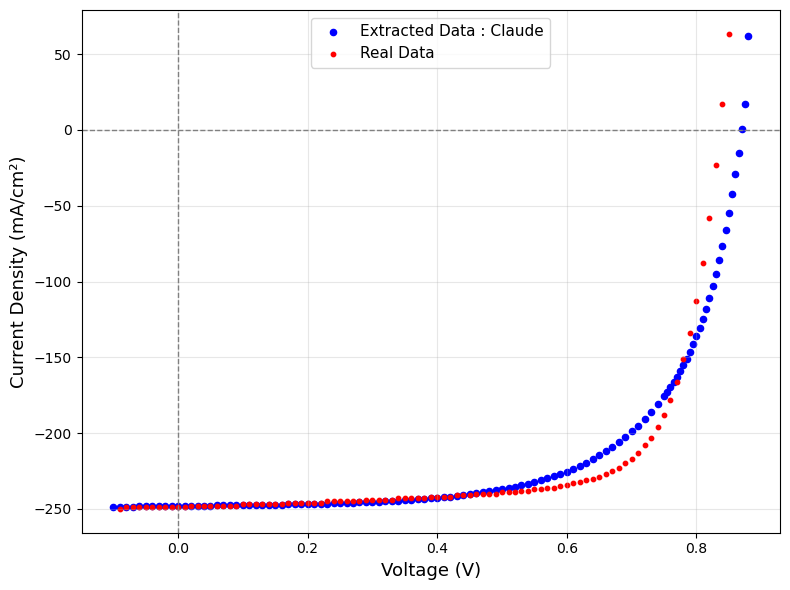

In [10]:
import matplotlib.pyplot as plt

# Extract V and J values into separate lists
V_values = [point["V"] for point in data_points]
J_values = [point["J"] for point in data_points]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(V_values, J_values, color="blue", s=20, label="Extracted Data : Claude")
ax.scatter(jv_data["Vext"], jv_data["Jext"], color="red", s=10, label="Real Data")

# Add vertical and horizontal lines for Voc and Jsc
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# # Mark key parameters on the plot
# ax.axhline(y=-parameters["Jsc"], color='red', linestyle=':', linewidth=1.5, label=f"Jsc = {parameters['Jsc']} mA/cm²")
# ax.axvline(x=parameters["Voc"], color='green', linestyle=':', linewidth=1.5, label=f"Voc = {parameters['Voc']} V")

# Labels and title
ax.set_xlabel("Voltage (V)", fontsize=13)
ax.set_ylabel("Current Density (mA/cm²)", fontsize=13)
#ax.set_title(f"Extracted J-V Curve\nPCE = {parameters['PCE']}%  |  FF = {parameters['FF']}", fontsize=14)

# Add legend
ax.legend(fontsize=11)

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

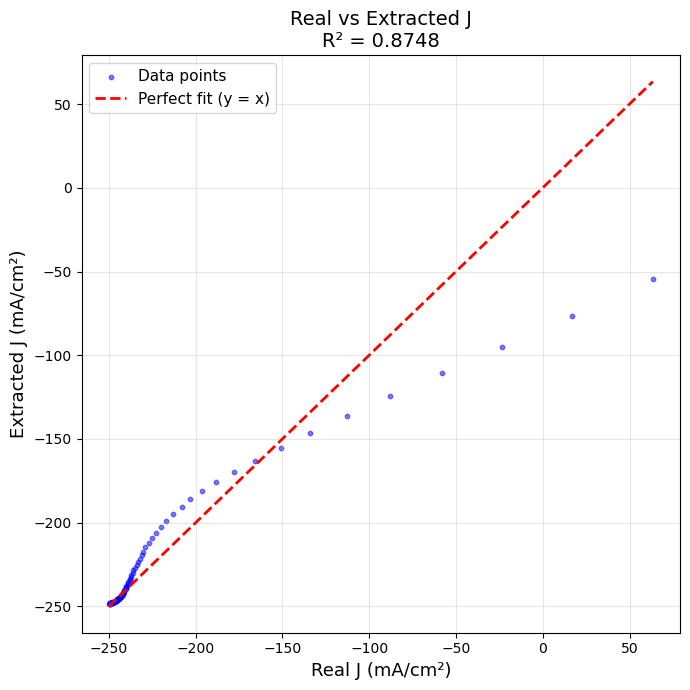

R² Score: 0.8748


In [11]:
# Calculate R2
import numpy as np
from scipy import interpolate
from sklearn.metrics import r2_score

interp_func = interpolate.interp1d(
    V_values, 
    J_values,
    kind="linear",  
    fill_value="extrapolate"  )

J_extrapolated = interp_func(jv_data["Vext"])
r2 = r2_score(jv_data["Jext"], J_extrapolated)


# Step 5: Plot
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(jv_data["Jext"], J_extrapolated,
           color="blue", s=10, alpha=0.5, label="Data points")

# Perfect fit line y = x
min_val = min(jv_data["Jext"].min(), J_extrapolated.min())
max_val = max(jv_data["Jext"].max(), J_extrapolated.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2, label="Perfect fit (y = x)")

ax.set_xlabel("Real J (mA/cm²)", fontsize=13)
ax.set_ylabel("Extracted J (mA/cm²)", fontsize=13)
ax.set_title(f"Real vs Extracted J\nR² = {round(r2, 4)}", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("R² Score:", round(r2, 4))

## 2. ChatGPT

In [ ]:
#pip install openai

In [ ]:
#pip show openai

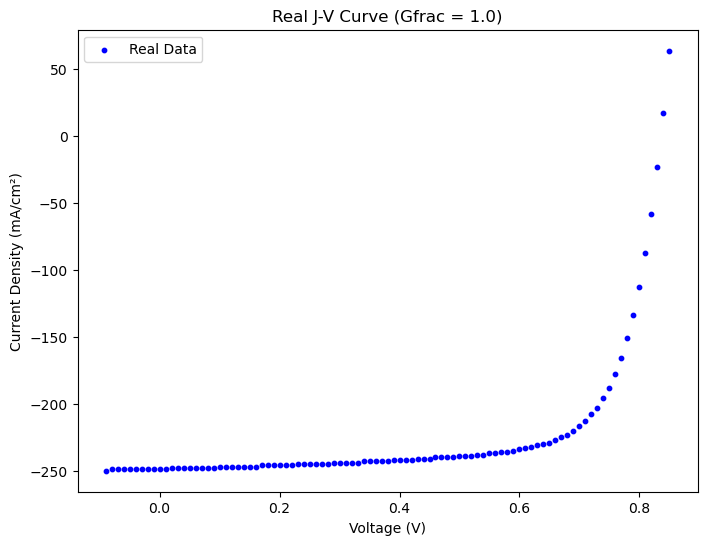

In [12]:
from openai import OpenAI
client_openai = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

import pandas as pd
import matplotlib.pyplot as plt

# Load and filter data
data = pd.read_csv("0min_cell_4.csv")
data = data[data["Gfrac"] == 1.0]
jv_data = data[(data["Vext"] > -0.1) & (data["Jext"] < 100)]
jv_data = jv_data.reset_index(drop=True)

# Plot and save as image
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(jv_data["Vext"], jv_data["Jext"], color="blue", s=10, label="Real Data")
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Current Density (mA/cm²)")
ax.set_title("Real J-V Curve (Gfrac = 1.0)")
ax.legend()
#ax.grid(True, alpha=0.3)

# Save to images folder
plt.savefig("image/jv_real_gpt.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
from PIL import Image
img = Image.open("image/jv_real_gpt.png")
print("Width:", img.size[0], "pixels")
print("Height:", img.size[1], "pixels")
print("Full size:", img.size)
print("DPI:", img.info.get("dpi", "Not stored in file"))
print("Mode:", img.mode)  # RGB, RGBA etc

Width: 1060 pixels
Height: 817 pixels
Full size: (1060, 817)
DPI: (150.01239999999999, 150.01239999999999)
Mode: RGBA


In [ ]:
# from PIL import Image, ImageEnhance, ImageFilter

# img = Image.open("image/jv_real.png")
# # Upscale
# img = img.resize((8000, 8000), Image.LANCZOS)
# # Sharpen
# img = img.filter(ImageFilter.SHARPEN)
# # Increase contrast
# enhancer = ImageEnhance.Contrast(img)
# img = enhancer.enhance(2.0)
# img.save("image/figure_enhanced_5.png", dpi=(400,400))
# img

In [14]:
from PIL import Image
img = Image.open("image/jv_real_gpt.png")
print("Width:", img.size[0], "pixels")
print("Height:", img.size[1], "pixels")
print("Full size:", img.size)
print("DPI:", img.info.get("dpi", "Not stored in file"))
print("Mode:", img.mode)  # RGB, RGBA etc

Width: 1060 pixels
Height: 817 pixels
Full size: (1060, 817)
DPI: (150.01239999999999, 150.01239999999999)
Mode: RGBA


In [15]:
import base64
from pathlib import Path

image_path = Path('image/jv_real_gpt.png')
if image_path.exists():
    print('Image found')
else:
    print('Image not found')

Image found


In [16]:
# Read the image as raw bytes
image_bytes = image_path.read_bytes()
# Convert raw bytes to base64 string
base64_image = base64.b64encode(image_bytes).decode("utf-8")
print("Type:", type(base64_image))
print("First 50 characters:", base64_image[:50])

Type: <class 'str'>
First 50 characters: iVBORw0KGgoAAAANSUhEUgAABCQAAAMxCAYAAAAzKmKvAAAAOX


In [17]:
import json

response_gpt = client_openai.chat.completions.create(
    model="gpt-5.5",
    #model="gpt-4o",
    max_completion_tokens=12000,
    response_format={"type": "json_object"},
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}",
                        "detail": "high"
                    }
                },
                {
                    "type": "text",
                    "text": """I am a photovoltaic solar cell researcher. This is my own experimental J-V curve image.
I lost the original numerical data file, so I need to digitize the visible curve from this image.
You are an expert in photovoltaic J-V curve analysis and scientific plot digitization.

IMPORTANT:
- Perform the best possible visual digitization from the image.
- Do not suggest WebPlotDigitizer, Engauge Digitizer, or any other external tools.
- The extracted values must be based only on the visible experimental curve.
- Return JSON only. No explanation, no markdown, no extra text.

Your tasks:
1. Identify the plot area only.
   - Ignore margins, legend, title, axis labels, and other text outside the plot box.
   - Use only the actual plotting region for calibration.

2. Read the axes carefully.
   - x-axis: Voltage, unit V.
   - y-axis: Current Density, unit mA/cm^2.
   - Pay special attention to negative current-density values.

3. Extract data points:
   - Map tick label positions to real V and J values to calibrate pixel-to-value conversion.
   - Detect the maximum power point/knee region of the curve.
   - In this region, read both V and J coordinates very carefully.
   - Small pixel errors can cause large J errors in the steep region.
   - Cross-check each point against the nearest tick labels.
   - Extract 1 point every 0.01V across flat regions of the visible curve.
   - Extract 1 point every 0.005V across knee and forward-bias regions of the visible J-V curve.
   - Do NOT stop extraction at Voc.
   - Voc is only the voltage where J crosses 0 mA/cm^2.
   - Positive current density values above 0 mA/cm^2 are valid experimental J-V data.
   - If the visible curve extends above J = 0, the final data_points list must include positive J values.
   - CRITICAL: Only extract a point if the experimental curve or marker is CLEARLY VISIBLE at that voltage.
   - Do NOT guess, interpolate, or invent points between visible markers.
   - Read from the center of the visible curve line or marker.
   - Ignore axes, grid lines, legend symbols, and text.

4. Sort all extracted points by increasing voltage.

Return the answer in this exact JSON structure:
{
  "data_points": [
    {"V": 0.00, "J": 0.00}
  ]
}"""
                }
            ]
        }
    ]
)

raw_text_gpt = response_gpt.choices[0].message.content
print(raw_text_gpt)

{"data_points":[{"V":-0.09,"J":-250.2},{"V":-0.08,"J":-250.0},{"V":-0.07,"J":-249.9},{"V":-0.06,"J":-249.8},{"V":-0.05,"J":-249.7},{"V":-0.04,"J":-249.6},{"V":-0.03,"J":-249.5},{"V":-0.02,"J":-249.4},{"V":-0.01,"J":-249.2},{"V":0.0,"J":-249.1},{"V":0.01,"J":-248.9},{"V":0.02,"J":-248.8},{"V":0.03,"J":-248.6},{"V":0.04,"J":-248.5},{"V":0.05,"J":-248.3},{"V":0.06,"J":-248.1},{"V":0.07,"J":-247.9},{"V":0.08,"J":-247.7},{"V":0.09,"J":-247.5},{"V":0.1,"J":-247.3},{"V":0.11,"J":-247.1},{"V":0.12,"J":-246.9},{"V":0.13,"J":-246.7},{"V":0.14,"J":-246.5},{"V":0.15,"J":-246.3},{"V":0.16,"J":-246.1},{"V":0.17,"J":-245.9},{"V":0.18,"J":-245.7},{"V":0.19,"J":-245.5},{"V":0.2,"J":-245.3},{"V":0.21,"J":-245.1},{"V":0.22,"J":-244.9},{"V":0.23,"J":-244.7},{"V":0.24,"J":-244.5},{"V":0.25,"J":-244.3},{"V":0.26,"J":-244.1},{"V":0.27,"J":-243.9},{"V":0.28,"J":-243.7},{"V":0.29,"J":-243.5},{"V":0.3,"J":-243.3},{"V":0.31,"J":-243.1},{"V":0.32,"J":-242.9},{"V":0.33,"J":-242.7},{"V":0.34,"J":-242.4},{"V":0.35,"

In [18]:
import json
import re

# Step 1: Get text from GPT response (different from Claude!)
raw_text_gpt = response_gpt.choices[0].message.content

# Step 2: Clean and parse JSON
clean_text_gpt = re.sub(r'```json|```', '', raw_text_gpt).strip()
gpt_output = json.loads(clean_text_gpt)

# Step 3: Extract data points — filter out positive J values
data_points_gpt = [p for p in gpt_output["data_points"] if p["J"] < 0]

# Step 4: Print results
print("Total data points extracted:", len(data_points_gpt))
print("\nFirst 3 data points:")
for point in data_points_gpt[:3]:
    print("  V:", point["V"], "  J:", point["J"])

Total data points extracted: 93

First 3 data points:
  V: -0.09   J: -250.2
  V: -0.08   J: -250.0
  V: -0.07   J: -249.9


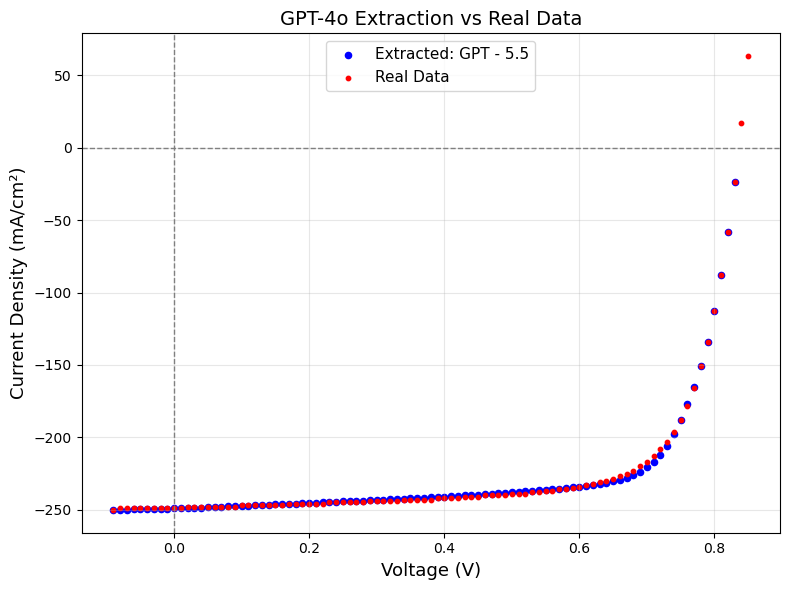

In [21]:
import matplotlib.pyplot as plt

# Extract V and J values from GPT output
V_values_gpt = [point["V"] for point in data_points_gpt]
J_values_gpt = [point["J"] for point in data_points_gpt]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(V_values_gpt, J_values_gpt, color="blue", s=20, label="Extracted: GPT - 5.5")
ax.scatter(jv_data["Vext"], jv_data["Jext"], color="red", s=10, label="Real Data")

# Add vertical and horizontal lines
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# Labels and title
ax.set_xlabel("Voltage (V)", fontsize=13)
ax.set_ylabel("Current Density (mA/cm²)", fontsize=13)
ax.set_title("GPT-4o Extraction vs Real Data", fontsize=14)

# Add legend and grid
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

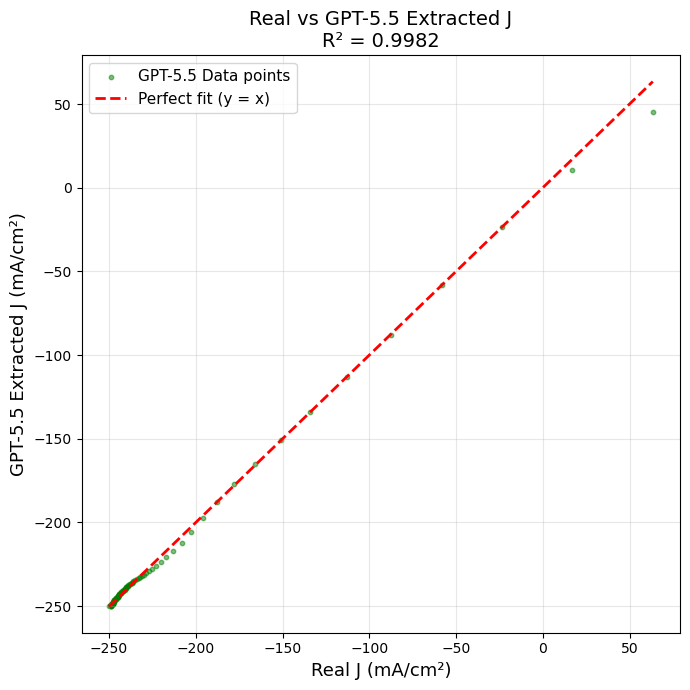

GPT-5.5 R² Score: 0.9982


In [26]:
import numpy as np
from scipy import interpolate
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Calculate R² for GPT-4o
interp_func_gpt = interpolate.interp1d(
    V_values_gpt,
    J_values_gpt,
    kind="linear",
    fill_value="extrapolate"
)
J_extrapolated_gpt = interp_func_gpt(jv_data["Vext"])
r2_gpt = r2_score(jv_data["Jext"], J_extrapolated_gpt)

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(jv_data["Jext"], J_extrapolated_gpt,
           color="green", s=10, alpha=0.5, label="GPT-5.5 Data points")

# Perfect fit line y = x
min_val = min(jv_data["Jext"].min(), J_extrapolated_gpt.min())
max_val = max(jv_data["Jext"].max(), J_extrapolated_gpt.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2, label="Perfect fit (y = x)")

ax.set_xlabel("Real J (mA/cm²)", fontsize=13)
ax.set_ylabel("GPT-5.5 Extracted J (mA/cm²)", fontsize=13)
ax.set_title(f"Real vs GPT-5.5 Extracted J\nR² = {round(r2_gpt, 4)}", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("GPT-5.5 R² Score:", round(r2_gpt, 4))

Study 2 — Automated J-V Data Extraction from Research Articles Development of a pipeline to extract J-V curve data and key photovoltaic parameters (Voc, Jsc, FF, PCE) directly from full-text research articles, including automatic figure detection, localization, and digitization from PDF documents.

Study 3 — Large-Scale Automated Data Mining via Web Search Implementation of an automated web search pipeline to systematically 
collect and extract J-V characteristics from recent photovoltaic discoveries across multiple journals and preprint servers, 
enabling construction of a comprehensive, up-to-date solar cell performance database.